In [29]:
import torch
import os
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch.utils.data
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil
import torchvision
from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    CenterCrop
)
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

In [30]:
import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [31]:
class HangestenDatensatz(Dataset):
    
    def __init__(self, df, label_map, custom_transform):
        self.df = list(zip(df['path'], df['label']))
        self.label_map = label_map
        self.custom_transform = custom_transform
        self.num_frames = 30
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        video_path, labels = self.df[index]
        video_tensor = self.read(video_path, transform=self.custom_transform)
        label = self.label_map[labels]

        return video_tensor, torch.tensor(label, dtype=torch.long)

    def read(self, video, transform):
        frames = []
        cap = cv2.VideoCapture(filename=video)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, total_frames-1, self.num_frames, dtype=int)

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                if frames:
                    frames.append(frames[-1])
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frames.append(transform(frame))
        cap.release()

        return torch.stack(frames)




In [32]:
label_map = {
    "geste_0": 0,
    "geste_1" :1,
    "geste_2": 2,
    "class_1": 3,
    "class_2": 4,
    "Gesture01":5,
    "Gesture02":6,
    "hand_turn":7,
    "ok_sign":8,
    "thumb_up":9
}

In [33]:
df = pd.read_csv("train.csv")

In [34]:
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomCrop((96, 96)),
    transforms.ColorJitter(brightness= 0.3, contrast =0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

val_transform = transforms.Compose(
    [transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))]
)

In [35]:
train_loader = DataLoader(HangestenDatensatz(df, label_map, transform), batch_size=16, num_workers=12,shuffle=True, pin_memory=True)

In [36]:
val_df = pd.read_csv("val.csv")
val_loader = DataLoader(HangestenDatensatz(val_df, label_map, val_transform), batch_size=16, num_workers=12,shuffle=True, pin_memory=True)

In [37]:
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

In [38]:
class mobilenet_handgesten(nn.Module):

    def __init__(self, num_classes: int = 10, hidden_dim: int = 128,
                    num_layers: int = 2, freeze_backbone: bool = True):
            super().__init__()

            backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
            # Drop the classification head; keep only the conv feature extractor
            self.feature_extractor = backbone.features   # outputs (B, 576, h, w)
            self.avgpool = nn.AdaptiveAvgPool2d(1)
            feature_dim = 576  # MobileNetV3-Small final channel count

            if freeze_backbone:
                for param in self.feature_extractor.parameters():
                    param.requires_grad = False

            self.lstm = nn.LSTM(
                input_size=feature_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=0.3,
                bidirectional=True,
            )
            self.classifier = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(hidden_dim * 2, num_classes),  # *2 for bidirectional
            )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)                          # merge batch & time
        feats = self.avgpool(self.feature_extractor(x))      # (B*T, 576, 1, 1)
        feats = feats.flatten(1)                             # (B*T, 576)
        feats = feats.view(B, T, -1)                         # (B, T, 576)
        out, _ = self.lstm(feats)                            # (B, T, hidden*2)
        return self.classifier(out[:, -1, :])                # last timestep

In [39]:
device = "cuda"
model = mobilenet_handgesten(num_classes=10, hidden_dim=128, num_layers=2, freeze_backbone=True).to(device)
pretrained_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
pretrained_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    pretrained_optimizer, T_max=50
)
pretrained_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [40]:
best_val_acc_pretrained = 0.0
pretrained_train_accs, pretrained_val_accs = [], []

for epoch in range(1, 51):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)
        pretrained_optimizer.zero_grad(set_to_none=True)
        outputs = model(videos)
        loss = pretrained_criterion(outputs, labels)
        loss.backward()
        pretrained_optimizer.step()

        train_loss    += loss.item() * videos.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total   += videos.size(0)

    pretrained_scheduler.step()

    # ── Unfreeze last backbone block at epoch 20 for gradual fine-tuning ───
    if epoch == 20:
        last_block = list(model.feature_extractor.children())[-1]
        for param in last_block.parameters():
            param.requires_grad = True
        pretrained_optimizer.add_param_group({"params": last_block.parameters(), "lr": 1e-5})
        print("Epoch 20: unfroze last backbone block for fine-tuning")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    train_acc = train_correct / train_total
    val_acc   = val_correct / val_total * 100
    pretrained_train_accs.append(train_acc * 100)
    pretrained_val_accs.append(val_acc)

    if val_acc > best_val_acc_pretrained:
        best_val_acc_pretrained = val_acc
        torch.save(model.state_dict(), "model_pretrained_best.pth")

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train acc: {train_acc*100:.1f}%  "
              f"val acc: {val_acc:.1f}%  (best: {best_val_acc_pretrained:.1f}%)")


Epoch  10 | train acc: 95.6%  val acc: 60.5%  (best: 71.1%)
Epoch 20: unfroze last backbone block for fine-tuning
Epoch  20 | train acc: 100.0%  val acc: 86.8%  (best: 90.8%)
Epoch  30 | train acc: 100.0%  val acc: 88.2%  (best: 90.8%)
Epoch  40 | train acc: 99.6%  val acc: 90.8%  (best: 90.8%)
Epoch  50 | train acc: 99.6%  val acc: 89.5%  (best: 90.8%)


In [42]:
test_df = pd.read_csv("test.csv")

test_loader = DataLoader(HangestenDatensatz(test_df, label_map, val_transform), batch_size=16, shuffle=True, pin_memory=True, num_workers=12)

In [43]:
model.eval()

test_loss, test_correct, test_total = 0.0, 0, 0

with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)                    # (B, num_classes)
        loss = pretrained_criterion(outputs, labels)
        
        test_loss += loss.item() * videos.size(0)
        preds = outputs.argmax(dim=1)
        # _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()

avg_loss = test_loss / test_total
accuracy = (test_correct / test_total)*100

print(accuracy)

92.20779220779221


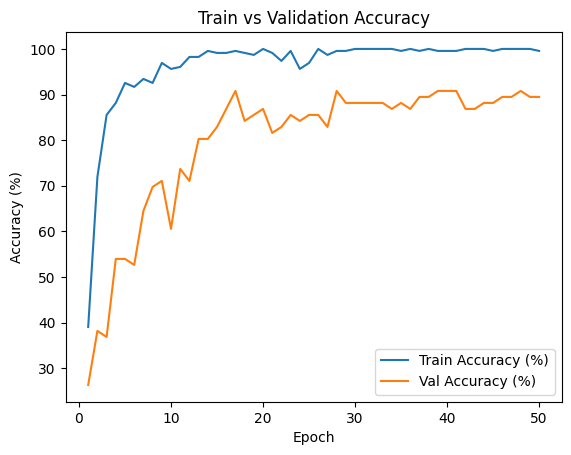

In [41]:
train_accs_pct = [acc * 100 for acc in pretrained_train_accs]  # convert to %

fig, ax = plt.subplots()
ax.plot(range(1, len(pretrained_train_accs) + 1), pretrained_train_accs, label="Train Accuracy (%)")
ax.plot(range(1, len(pretrained_val_accs) + 1), pretrained_val_accs, label="Val Accuracy (%)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Validation Accuracy")
ax.legend()
plt.show()

In [ ]:
import math

In [ ]:
class FullModel(nn.Module):

    def __init__(self, batch_size, seq_length=8):
        super(FullModel, self).__init__()
        
        class CNN2D(nn.Module):
            def __init__(self, batch_size=batch_size, image_size=96, seq_length=8, in_channels=3):
                super(CNN2D, self).__init__()
                self.conv1 = self._create_conv_layer(in_channels=in_channels, out_channels=16)
                self.conv2 = self._create_conv_layer(in_channels=16, out_channels=32)
                self.conv3 = self._create_conv_layer_pool(in_channels=32, out_channels=64)
                self.conv4 = self._create_conv_layer_pool(in_channels=64, out_channels=128)
                self.conv5 = self._create_conv_layer_pool(in_channels=128, out_channels=256)
                cnn_output_shape = int(256*(image_size/(2**4))**2)

            def forward(self, x):
                batch_size, frames, channels, width, height = x.shape
                x = x.view(-1, channels, width, height)
                x = self.conv1(x)
                x = self.conv2(x)
                x = self.conv3(x)
                x = self.conv4(x)
                x = self.conv5(x)
                return x
            
            def _create_conv_layer(self,in_channels, out_channels, kernel_size=(3,3), padding=(1,1)):
                return nn.Sequential(
                        nn.Conv2d(in_channels,out_channels, kernel_size, padding=padding),
                        nn.BatchNorm2d(out_channels),
                        nn.ReLU(),
                    )

            def _create_conv_layer_pool(self,in_channels, out_channels, kernel_size=(3,3), padding=(1,1), pool=(2,2)):
                return nn.Sequential(
                        nn.Conv2d(in_channels,out_channels, kernel_size, padding=padding),
                        nn.BatchNorm2d(out_channels),
                        nn.ReLU(),
                        nn.MaxPool2d(pool)
                    )

        class CNN3D(nn.Module):
            def __init__(self, batch_size=batch_size, image_size=96, seq_length=8):
                super(CNN3D, self).__init__()
                self.conv1 = self._create_conv_layer_pool(in_channels=256, out_channels=256, pool=(1,1,1))
                self.conv2 = self._create_conv_layer_pool(in_channels=256, out_channels=256, pool=(2,2,2))
                self.conv3 = self._create_conv_layer_pool(in_channels=256, out_channels=256, pool=(2,1,1))
                self.conv4 = self._create_conv_layer_pool(in_channels=256, out_channels=256, pool=(2,2,2))

            def forward(self, x):
                batch_size, channels, frames, width, height = x.shape
                x = self.conv1(x)
                x = self.conv2(x)
                x = self.conv3(x)
                x = self.conv4(x)
                return x

            def _create_conv_layer(self,in_channels, out_channels, kernel_size=(3,3,3), padding=(1,1,1)):
                return nn.Sequential(
                        nn.Conv3d(in_channels,out_channels, kernel_size, padding=padding),
                        nn.BatchNorm3d(out_channels),
                        nn.ReLU(),
                    )

            def _create_conv_layer_pool(self,in_channels, out_channels, kernel_size=(3,3,3), padding=(1,1,1), pool=(1,2,2)):
                return nn.Sequential(
                        nn.Conv3d(in_channels,out_channels, kernel_size, padding=padding),
                        nn.BatchNorm3d(out_channels),
                        nn.ReLU(),
                        nn.MaxPool3d(pool)
                    )


        class Combiner(nn.Module):
            
            def __init__(self, in_features):
                super(Combiner, self).__init__()
                self.linear1 = self._create_linear_layer(in_features , in_features//2)
                self.linear2 = self._create_linear_layer(in_features//2 , 1024)
                self.linear3 = self._create_linear_layer(1024 , 6)
                #self.linear3 = self._create_last_linear_layer(1024 , 6)

            def forward(self, x):
                x = self.linear1(x)
                x = self.linear2(x)
                x = self.linear3(x)
                return x;

            def _create_linear_layer(self, in_features, out_features, p=0.6):
                return nn.Sequential(
                    nn.Linear(in_features, out_features),
                    nn.Dropout(p=p)
                )
            
            def _create_last_linear_layer(self, in_features, out_features, p=0.6):
                return nn.Sequential(
                    nn.Linear(in_features, out_features),
                    nn.Softmax(out_features)
                )

        self.rgb2d = CNN2D(batch_size)
        self.rgb3d = CNN3D(batch_size)
        self.combiner = Combiner(4608)

        self.batch_size = batch_size
        self.seq_length = seq_length
        self.steps = 0
        self.steps = 0
        self.epochs = 0
        self.best_validation_loss = math.inf

    def forward(self, x):
        self.batch_size = x.shape[0]
        x = self.rgb2d(x)
        batch_and_frames, channels, dim1, dim2 = x.shape
        x = x.view(self.batch_size, -1, channels, dim1, dim2).permute(0,2,1,3,4)
        x = self.rgb3d(x)
        x = x.view(self.batch_size, -1)
        x = self.combiner(x)

        if self.training:
            self.steps += 1

        return x